--- Step 0: Checking Data Availability ---
[OK] Found SOYBEAN: Soybean_Competition_Exports_to_China_2015_2024.csv
[OK] Found TARIFF: Annual_Tariff_Index.csv
[OK] Found GDP: US_GDP_2015_2025.csv
[OK] Found CPI: US_CPI_2015_2025.csv

Part 1: Quantifying Structural Breaks in Soybean Competition
Fitting Pre-War Regime (2015-2017)...
Fitting Trade-War Regime (2018-2024)...

[RESULT] Quantitative Comparison of System Parameters:
                       Parameter  Pre-War (2015-2017)  Trade-War (2018-2024)  Change
               r_USA (US Growth)                0.513                  1.792   1.279
           r_BRA (Brazil Growth)                0.110                  0.086  -0.024
        r_ARG (Argentina Growth)                0.000                  2.000   2.000
       α_BRA->USA (Brazil vs US)                2.000                  1.573  -0.427
    α_ARG->USA (Argentina vs US)                2.000                  0.000  -2.000
       α_USA->BRA (US vs Brazil)                0.000          

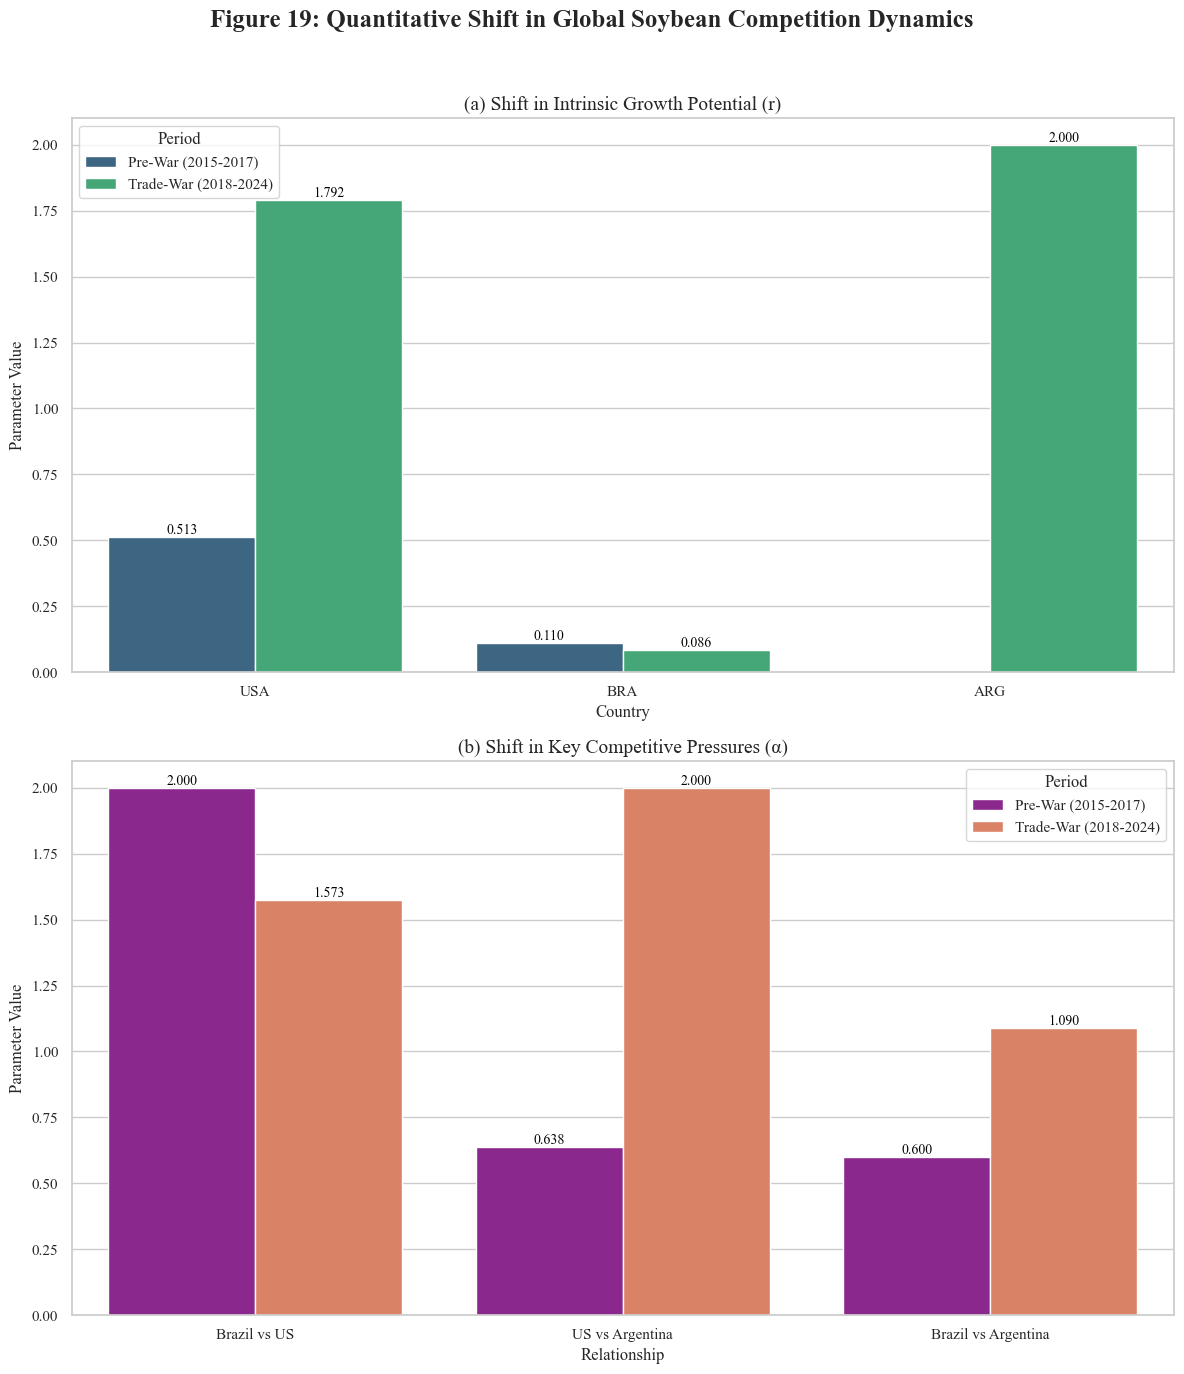


Part 2: Visualizing Trade Diversion (Sankey)
[SUCCESS] Part 2 Visualization saved to: G:\jupyter\2025APMCM\Cleaned_Data\Figure_17_Sankey_Diagram.html


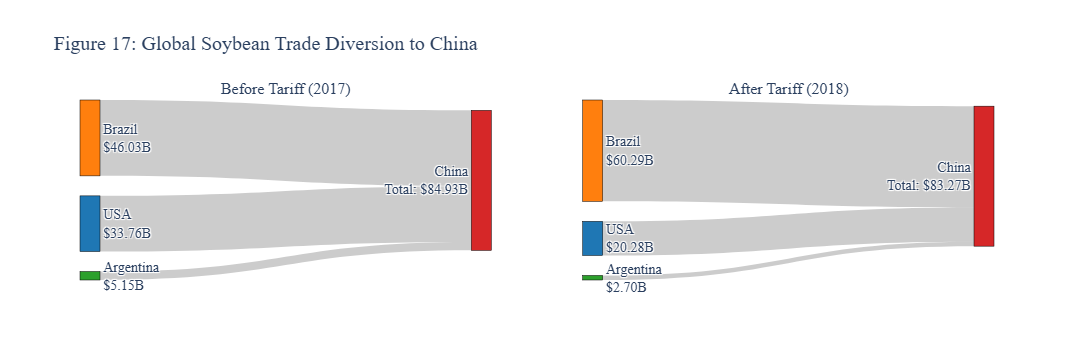


Part 3: Macroeconomic Impulse Response Analysis
Input Data for VAR (Head):
      General_Tau       GDP       CPI
Year                                 
2016    -0.041509  0.023554  0.009477
2017     0.076801  0.042924  0.021314
2018    -0.008797  0.053253  0.024390
2019    -0.090227  0.042769  0.018133
2020     0.299550 -0.007646  0.012529


G:\Anaconda3\envs\apmcm2025\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

G:\Anaconda3\envs\apmcm2025\lib\site-packages\statsmodels\tsa\vector_ar\irf.py:528: ComplexWarning:

Casting complex values to real discards the imaginary part

G:\Anaconda3\envs\apmcm2025\lib\site-packages\statsmodels\tsa\vector_ar\irf.py:528: ComplexWarning:

Casting complex values to real discards the imaginary part

G:\Anaconda3\envs\apmcm2025\lib\site-packages\statsmodels\tsa\vector_ar\irf.py:528: ComplexWarning:

Casting complex values to real discards the imaginary part

G:\Anaconda3\envs\apmcm2025\lib\site-packages\statsmodels\tsa\vector_ar\irf.py:528: ComplexWarning:

Casting complex values to real discards the imaginary part



[SUCCESS] Part 3 Visualization saved to: G:\jupyter\2025APMCM\Cleaned_Data\Figure_18_Macro_IRF_Horizontal.png


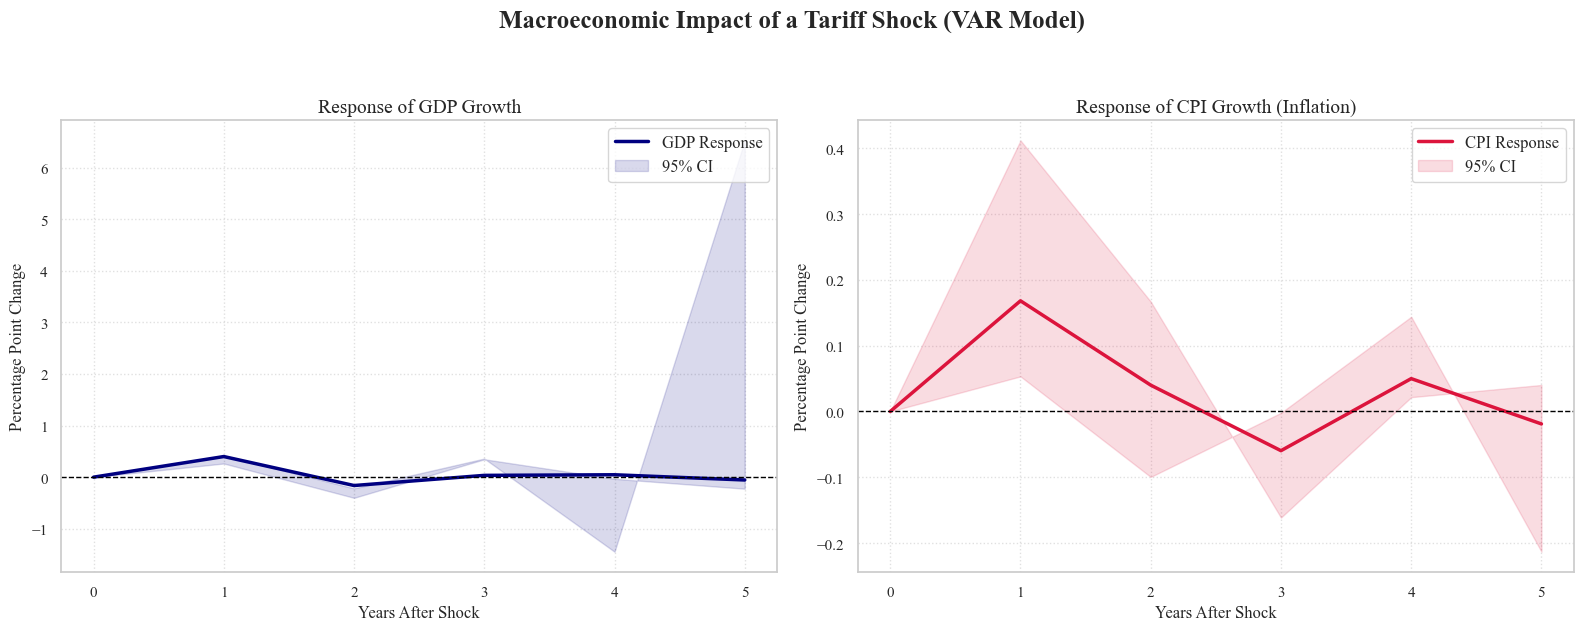


--- ALL TASKS COMPLETED SUCCESSFULLY ---


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from scipy.integrate import odeint
from scipy.optimize import minimize
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.tsa.api import VAR

# --- 0. 全局配置与文件检查 ---
BASE_DIR = r"G:\jupyter\2025APMCM"
TRADE_DIR = os.path.join(BASE_DIR, "Trade Data")
MACRO_DIR = os.path.join(BASE_DIR, "US_Macroeconomic")
CLEAN_DIR = os.path.join(BASE_DIR, "Cleaned_Data")
os.makedirs(CLEAN_DIR, exist_ok=True)

# 定义所需文件路径
FILES = {
    "SOYBEAN": os.path.join(TRADE_DIR, "Soybean_Competition_Exports_to_China_2015_2024.csv"),
    "TARIFF": os.path.join(CLEAN_DIR, "Annual_Tariff_Index.csv"),
    "GDP": os.path.join(MACRO_DIR, "US_GDP_2015_2025.csv"),
    "CPI": os.path.join(MACRO_DIR, "US_CPI_2015_2025.csv")
}

print("--- Step 0: Checking Data Availability ---")
missing_files = []
for name, path in FILES.items():
    if os.path.exists(path):
        print(f"[OK] Found {name}: {os.path.basename(path)}")
    else:
        print(f"[MISSING] Could not find {name} at: {path}")
        missing_files.append(name)

if missing_files:
    print("\n[CRITICAL ERROR] Missing necessary data files. Calculation cannot proceed.")
    print("Please ensure the files listed above exist in the correct folders.")
    # sys.exit() # 在Notebook中通常注释掉这行，以免杀掉内核，但在脚本中应保留

# ==============================================================================
# Part 1: 双体系竞争模型分析 (Dual-Regime Lotka-Volterra Analysis)
# ==============================================================================
print("\n" + "="*60)
print("Part 1: Quantifying Structural Breaks in Soybean Competition")
print("="*60)

# 1.1 加载与清洗大豆数据
df_soy = pd.read_csv(FILES["SOYBEAN"])
# 标准化年份
if 'refPeriodId' in df_soy.columns:
    df_soy['Year'] = df_soy['refPeriodId'].astype(str).str.slice(0, 4).astype(int)
else:
    df_soy['Year'] = df_soy['refYear']

# 标准化国家名称
country_map = {'USA': 'USA', 'United States': 'USA', 'Brazil': 'BRA', 'BRA': 'BRA', 'Argentina': 'ARG', 'ARG': 'ARG'}
df_soy['Country'] = df_soy['reporterISO'].map(country_map)
df_soy.dropna(subset=['Country'], inplace=True)

# 生成透视表 (单位: Billion USD)
df_pivot = df_soy.groupby(['Year', 'Country'])['fobvalue'].sum().unstack(fill_value=0) / 1e9
all_years = range(2015, 2025)
history_data = df_pivot.reindex(all_years).fillna(0)[['USA', 'BRA', 'ARG']]

# 1.2 定义 LV 模型与优化目标
def lv_model(x, t, params):
    U, B, A = x
    r_u, r_b, r_a, a_ub, a_ua, a_bu, a_ba, a_au, a_ab = params
    K = 160.0 # 固定环境容量
    U, B, A = max(U, 0), max(B, 0), max(A, 0) # 防止负值
    dUdt = r_u * U * (1 - (U + a_ub*B + a_ua*A)/K)
    dBdt = r_b * B * (1 - (B + a_bu*U + a_ba*A)/K)
    dAdt = r_a * A * (1 - (A + a_au*U + a_ab*B)/K)
    return [dUdt, dBdt, dAdt]

def objective(params, t, data_true):
    x0 = data_true[0]
    try:
        x_pred = odeint(lv_model, x0, t, args=(params,))
        return np.mean((x_pred - data_true)**2)
    except:
        return 1e6

# 1.3 分别拟合两个时期 (使用真实数据!)
pre_war_data = history_data.loc[2015:2017]
trade_war_data = history_data.loc[2018:2024]

# 拟合体系 A: 前贸易战 (2015-2017)
print("Fitting Pre-War Regime (2015-2017)...")
t_pre = np.arange(len(pre_war_data))
# 初始猜测: 假设美国增长强，竞争温和
init_guess_pre = [0.5, 0.1, 0.1, 0.1, 0.1, 0.5, 0.1, 0.1, 0.1] 
bnds = [(0.0, 2.0)] * 9 # 参数范围约束
res_pre = minimize(objective, init_guess_pre, args=(t_pre, pre_war_data.values), bounds=bnds, method='L-BFGS-B')
params_pre = res_pre.x

# 拟合体系 B: 贸易战 (2018-2024)
print("Fitting Trade-War Regime (2018-2024)...")
t_war = np.arange(len(trade_war_data))
# 初始猜测: 假设美国增长弱，巴西竞争强
init_guess_war = [0.1, 0.8, 0.1, 1.0, 0.1, 0.0, 0.1, 0.1, 0.1]
res_war = minimize(objective, init_guess_war, args=(t_war, trade_war_data.values), bounds=bnds, method='L-BFGS-B')
params_war = res_war.x

# 1.4 构建对比数据表
param_names = [
    'r_USA (US Growth)', 'r_BRA (Brazil Growth)', 'r_ARG (Argentina Growth)',
    'α_BRA->USA (Brazil vs US)', 'α_ARG->USA (Argentina vs US)',
    'α_USA->BRA (US vs Brazil)', 'α_ARG->BRA (Argentina vs Brazil)',
    'α_USA->ARG (US vs Argentina)', 'α_BRA->ARG (Brazil vs Argentina)'
]

comp_df = pd.DataFrame({
    'Parameter': param_names,
    'Pre-War (2015-2017)': params_pre,
    'Trade-War (2018-2024)': params_war
})
comp_df['Change'] = comp_df['Trade-War (2018-2024)'] - comp_df['Pre-War (2015-2017)']

print("\n[RESULT] Quantitative Comparison of System Parameters:")
print(comp_df.round(3).to_string(index=False))

# 1.5 可视化对比结果
sns.set_theme(style="whitegrid", font="Times New Roman")
fig, axes = plt.subplots(2, 1, figsize=(12, 14))
fig.suptitle('Figure 19: Quantitative Shift in Global Soybean Competition Dynamics', fontsize=18, fontweight='bold')

# (a) 内禀增长率对比
growth_df = comp_df[comp_df['Parameter'].str.startswith('r_')].copy()
growth_df['Country'] = growth_df['Parameter'].str.extract(r'r_(\w+)')
growth_melted = growth_df.melt(id_vars='Country', value_vars=['Pre-War (2015-2017)', 'Trade-War (2018-2024)'], var_name='Period', value_name='Value')

sns.barplot(data=growth_melted, x='Country', y='Value', hue='Period', ax=axes[0], palette='viridis')
axes[0].set_title('(a) Shift in Intrinsic Growth Potential (r)', fontsize=14)
axes[0].set_ylabel('Parameter Value')
for p in axes[0].patches:
    if p.get_height() > 0.001:
        axes[0].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=10, color='black')

# (b) 关键竞争系数对比
key_comp_params = ['α_BRA->USA (Brazil vs US)', 'α_USA->ARG (US vs Argentina)', 'α_BRA->ARG (Brazil vs Argentina)']
comp_subset = comp_df[comp_df['Parameter'].isin(key_comp_params)].copy()
comp_subset['Relationship'] = comp_subset['Parameter'].str.extract(r'\((.*)\)')
comp_melted = comp_subset.melt(id_vars='Relationship', value_vars=['Pre-War (2015-2017)', 'Trade-War (2018-2024)'], var_name='Period', value_name='Value')

sns.barplot(data=comp_melted, x='Relationship', y='Value', hue='Period', ax=axes[1], palette='plasma')
axes[1].set_title('(b) Shift in Key Competitive Pressures (α)', fontsize=14)
axes[1].set_ylabel('Parameter Value')
for p in axes[1].patches:
    if p.get_height() > 0.001:
        axes[1].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=10, color='black')

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_path_p1 = os.path.join(CLEAN_DIR, "Figure_19_Parameter_Shift.png")
plt.savefig(save_path_p1, dpi=300)
print(f"[SUCCESS] Part 1 Visualization saved to: {save_path_p1}")
plt.show()


# ==============================================================================
# Part 2: 桑基图 (Sankey Diagram)
# ==============================================================================
print("\n" + "="*60)
print("Part 2: Visualizing Trade Diversion (Sankey)")
print("="*60)

data_2017 = history_data.loc[2017]
data_2018 = history_data.loc[2018]

# 动态生成标签 (带真实数值)
labels_2017 = [
    f"USA<br>${data_2017['USA']:.2f}B", f"Brazil<br>${data_2017['BRA']:.2f}B", f"Argentina<br>${data_2017['ARG']:.2f}B",
    f"China<br>Total: ${data_2017.sum():.2f}B"
]
labels_2018 = [
    f"USA<br>${data_2018['USA']:.2f}B", f"Brazil<br>${data_2018['BRA']:.2f}B", f"Argentina<br>${data_2018['ARG']:.2f}B",
    f"China<br>Total: ${data_2018.sum():.2f}B"
]
node_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig_sankey = make_subplots(rows=1, cols=2, specs=[[{'type': 'domain'}, {'type': 'domain'}]], 
                           subplot_titles=("Before Tariff (2017)", "After Tariff (2018)"))

fig_sankey.add_trace(go.Sankey(
    node=dict(pad=20, thickness=20, line=dict(color="black", width=0.5), label=labels_2017, color=node_colors),
    link=dict(source=[0, 1, 2], target=[3, 3, 3], value=data_2017.values)
), 1, 1)

fig_sankey.add_trace(go.Sankey(
    node=dict(pad=20, thickness=20, line=dict(color="black", width=0.5), label=labels_2018, color=node_colors),
    link=dict(source=[0, 1, 2], target=[3, 3, 3], value=data_2018.values)
), 1, 2)

fig_sankey.update_layout(title_text="Figure 17: Global Soybean Trade Diversion to China", font_size=14, font_family="Times New Roman")
save_path_p2 = os.path.join(CLEAN_DIR, "Figure_17_Sankey_Diagram.html")
fig_sankey.write_html(save_path_p2)
print(f"[SUCCESS] Part 2 Visualization saved to: {save_path_p2}")
fig_sankey.show()


# ==============================================================================
# Part 3: 宏观 VAR 模型 (Macroeconomic Impact)
# ==============================================================================
print("\n" + "="*60)
print("Part 3: Macroeconomic Impulse Response Analysis")
print("="*60)

# 3.1 加载并合并宏观数据
df_tau = pd.read_csv(FILES["TARIFF"])
df_gdp_raw = pd.read_csv(FILES["GDP"])
df_cpi_raw = pd.read_csv(FILES["CPI"])

# 鲁棒的列名处理函数
def process_macro(df, val_name):
    date_col = [c for c in df.columns if 'date' in c.lower()][0]
    val_col = [c for c in df.columns if c != date_col][0]
    df['Year'] = pd.to_datetime(df[date_col]).dt.year
    return df.groupby('Year')[val_col].mean().reset_index().rename(columns={val_col: val_name})

df_gdp = process_macro(df_gdp_raw, 'GDP')
df_cpi = process_macro(df_cpi_raw, 'CPI')

# 合并数据
df_macro = pd.merge(df_tau[['Year', 'General_Tau']], df_gdp, on='Year')
df_macro = pd.merge(df_macro, df_cpi, on='Year').set_index('Year')

# 3.2 数据变换 (百分比变化) 与 模型拟合
df_pct = df_macro.pct_change().dropna()
print("Input Data for VAR (Head):")
print(df_pct.head())

model_var = VAR(df_pct)
results_var = model_var.fit(1)
irf = results_var.irf(5)

# 3.3 绘制脉冲响应图 (Matplotlib) - 修改为左右排版
# figsize=(16, 6) 让图片变宽，适应左右布局
# 1, 2 表示 1 行 2 列
fig_var, axes_var = plt.subplots(1, 2, figsize=(16, 6), sharey=False) 

# 设置总标题
fig_var.suptitle("Macroeconomic Impact of a Tariff Shock (VAR Model)", fontsize=18, fontweight='bold', y=1.05)

# 提取数据 (保持不变)
gdp_idx = df_pct.columns.get_loc('GDP')
cpi_idx = df_pct.columns.get_loc('CPI')
tau_idx = df_pct.columns.get_loc('General_Tau')

irf_gdp = irf.irfs[:, gdp_idx, tau_idx]
ci_gdp_low = irf.err_band_sz1(orth=False)[0][:, gdp_idx, tau_idx]
ci_gdp_high = irf.err_band_sz1(orth=False)[1][:, gdp_idx, tau_idx]

irf_cpi = irf.irfs[:, cpi_idx, tau_idx]
ci_cpi_low = irf.err_band_sz1(orth=False)[0][:, cpi_idx, tau_idx]
ci_cpi_high = irf.err_band_sz1(orth=False)[1][:, cpi_idx, tau_idx]

# --- 左图：绘制 GDP ---
axes_var[0].plot(irf_gdp, color='navy', lw=2.5, label='GDP Response')
axes_var[0].fill_between(range(len(irf_gdp)), ci_gdp_low, ci_gdp_high, color='navy', alpha=0.15, label='95% CI')
axes_var[0].axhline(0, color='black', ls='--', lw=1)
axes_var[0].set_title("Response of GDP Growth", fontsize=14)
axes_var[0].set_ylabel("Percentage Point Change", fontsize=12)
axes_var[0].set_xlabel("Years After Shock", fontsize=12) # 左图也加上横坐标标签
axes_var[0].legend(loc='upper right', fontsize=12)
axes_var[0].grid(True, ls=':', alpha=0.6)

# --- 右图：绘制 CPI ---
axes_var[1].plot(irf_cpi, color='crimson', lw=2.5, label='CPI Response')
axes_var[1].fill_between(range(len(irf_cpi)), ci_cpi_low, ci_cpi_high, color='crimson', alpha=0.15, label='95% CI')
axes_var[1].axhline(0, color='black', ls='--', lw=1)
axes_var[1].set_title("Response of CPI Growth (Inflation)", fontsize=14)
# 如果想共享Y轴标签可以注释掉下面这行，但通常左右排版各自保留比较清晰
axes_var[1].set_ylabel("Percentage Point Change", fontsize=12) 
axes_var[1].set_xlabel("Years After Shock", fontsize=12)
axes_var[1].legend(loc='upper right', fontsize=12)
axes_var[1].grid(True, ls=':', alpha=0.6)

# 调整布局，防止标签重叠
plt.tight_layout()

# 保存与展示
save_path_p3 = os.path.join(CLEAN_DIR, "Figure_18_Macro_IRF_Horizontal.png")
plt.savefig(save_path_p3, dpi=300, bbox_inches='tight')
print(f"[SUCCESS] Part 3 Visualization saved to: {save_path_p3}")
plt.show()

print("\n--- ALL TASKS COMPLETED SUCCESSFULLY ---")